# Grid corpus analysis

Loads the corpus produced by `env_generator.py` (default `dev/grids/`) and:

1. Plots per-split histograms of every metadata descriptor.
2. Plots pairwise scatterplots with Spearman correlations between selected descriptors, to expose confounds.
3. Runs cheap non-communicating baseline policies (nearest, fixed-RB, fixed-BR, wait-and-react, random, oracle), reports per-layout success rates, and derives a **triviality** score for each layout.

In [1]:
from __future__ import annotations

import json
import random
from collections import deque
from pathlib import Path
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap
from matplotlib.patches import Circle, Rectangle
from scipy.stats import spearmanr

CORPUS_DIR = Path("grids")   # relative to this notebook (dev/grids)
SPLITS = ["train", "test", "val"]

# Cell codes as in env_generator.py.
EMPTY, WALL, RED, BLUE, EGO, PARTNER = 0, 1, 2, 3, 4, 5

## Load

In [ ]:
def load_split(split: str) -> Tuple[pd.DataFrame, Dict[str, dict]]:
    rows = []
    envs: Dict[str, dict] = {}
    for path in sorted((CORPUS_DIR / "layouts" / split).glob("*.json")):
        d = json.load(open(path))
        # Baselines (below) run through CoordinationGrid, which needs the source path.
        d["_path"] = str(path.resolve())
        rows.append({"layout_id": d["layout_id"], "seed": d["seed"], **d["metadata"]})
        envs[d["layout_id"]] = d
    return pd.DataFrame(rows), envs


dfs: Dict[str, pd.DataFrame] = {}
envs_by_split: Dict[str, Dict[str, dict]] = {}
for split in SPLITS:
    dfs[split], envs_by_split[split] = load_split(split)
    print(f"{split:5s}  {len(dfs[split]):4d} layouts")

## 1. Per-split metadata histograms

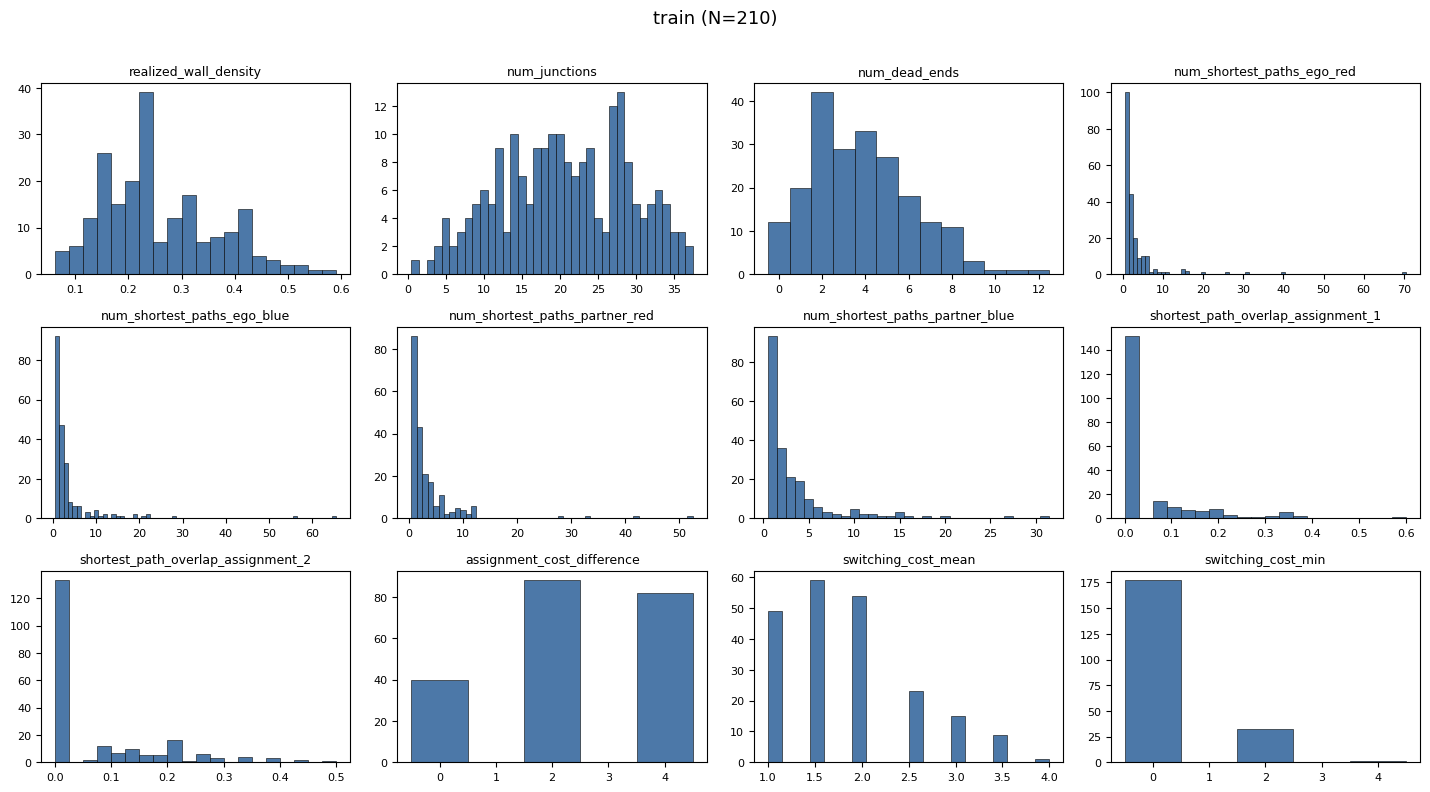

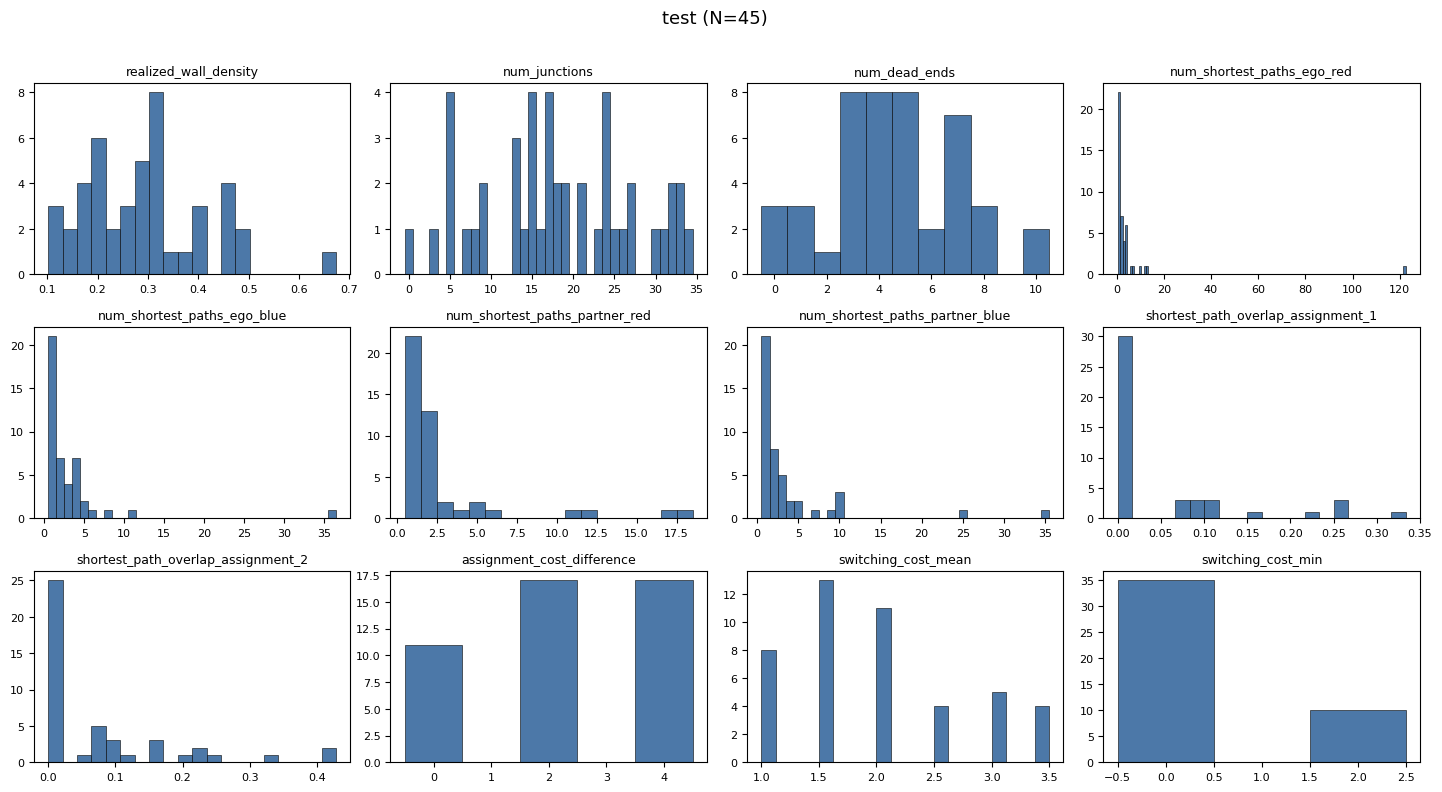

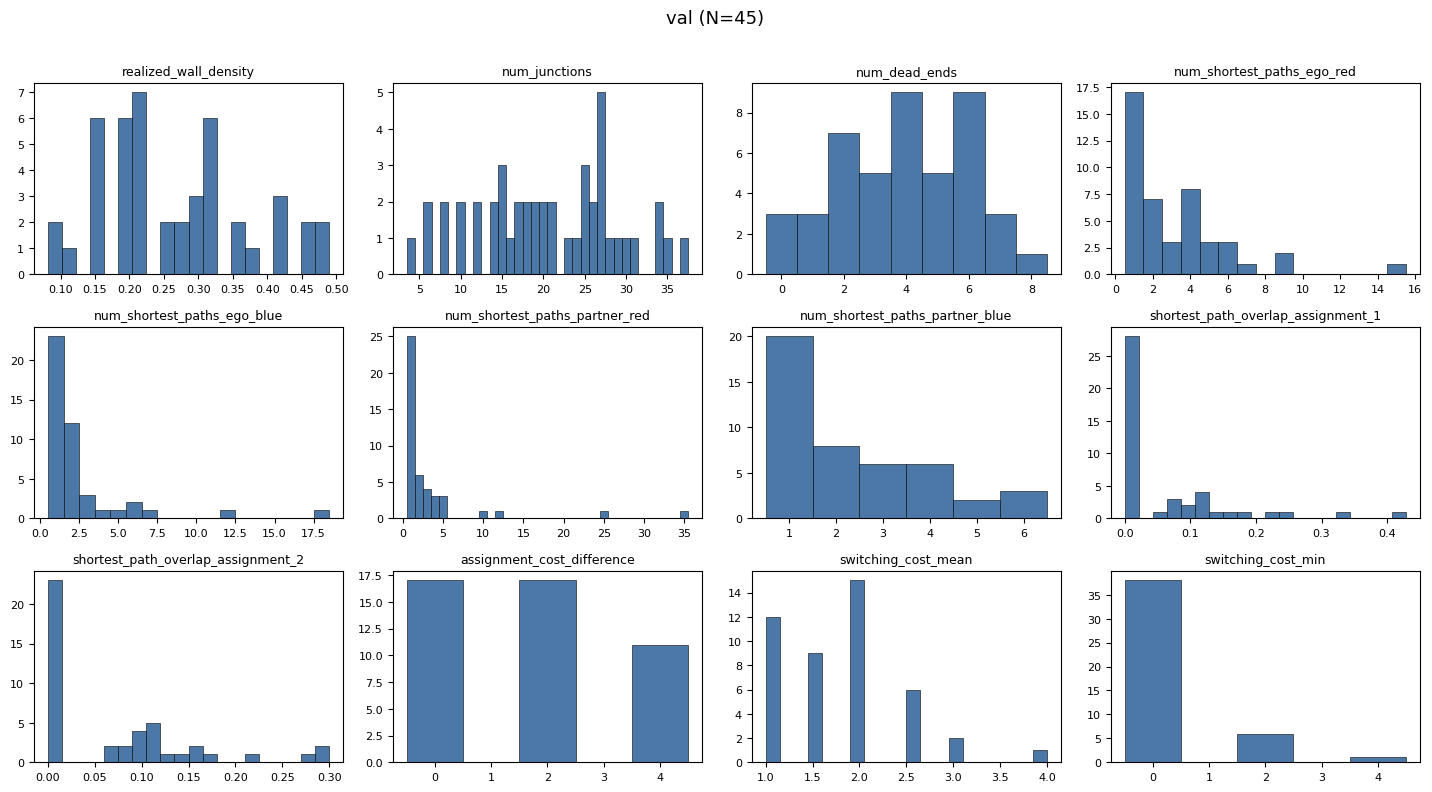

In [3]:
HIST_FIELDS = [
    "realized_wall_density",
    "num_junctions",
    "num_dead_ends",
    "num_shortest_paths_ego_red",
    "num_shortest_paths_ego_blue",
    "num_shortest_paths_partner_red",
    "num_shortest_paths_partner_blue",
    "shortest_path_overlap_assignment_1",
    "shortest_path_overlap_assignment_2",
    "assignment_cost_difference",
    "switching_cost_mean",
    "switching_cost_min",
]

def plot_hists(df: pd.DataFrame, title: str, cols: int = 4):
    n = len(HIST_FIELDS)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(3.6 * cols, 2.6 * rows))
    for i, f in enumerate(HIST_FIELDS):
        ax = axes.flat[i]
        vals = df[f].to_numpy()
        # Integer-valued fields get one bin per integer up to a cap.
        if np.issubdtype(vals.dtype, np.integer) or np.all(vals == vals.astype(int)):
            lo, hi = int(vals.min()), int(vals.max())
            bins = np.arange(lo, hi + 2) - 0.5
        else:
            bins = 20
        ax.hist(vals, bins=bins, color="#4C78A8", edgecolor="black", linewidth=0.4)
        ax.set_title(f, fontsize=9)
        ax.tick_params(labelsize=8)
    for j in range(n, rows * cols):
        axes.flat[j].axis("off")
    fig.suptitle(title, fontsize=13, y=1.01)
    fig.tight_layout()
    return fig

for split in SPLITS:
    plot_hists(dfs[split], f"{split} (N={len(dfs[split])})")
    plt.show()

## 2. Pairwise scatter + Spearman ρ

Uses the train split (pool of the two others is fine too, but we want to inspect one). Extend the `PAIRS` list to look at anything else you suspect.

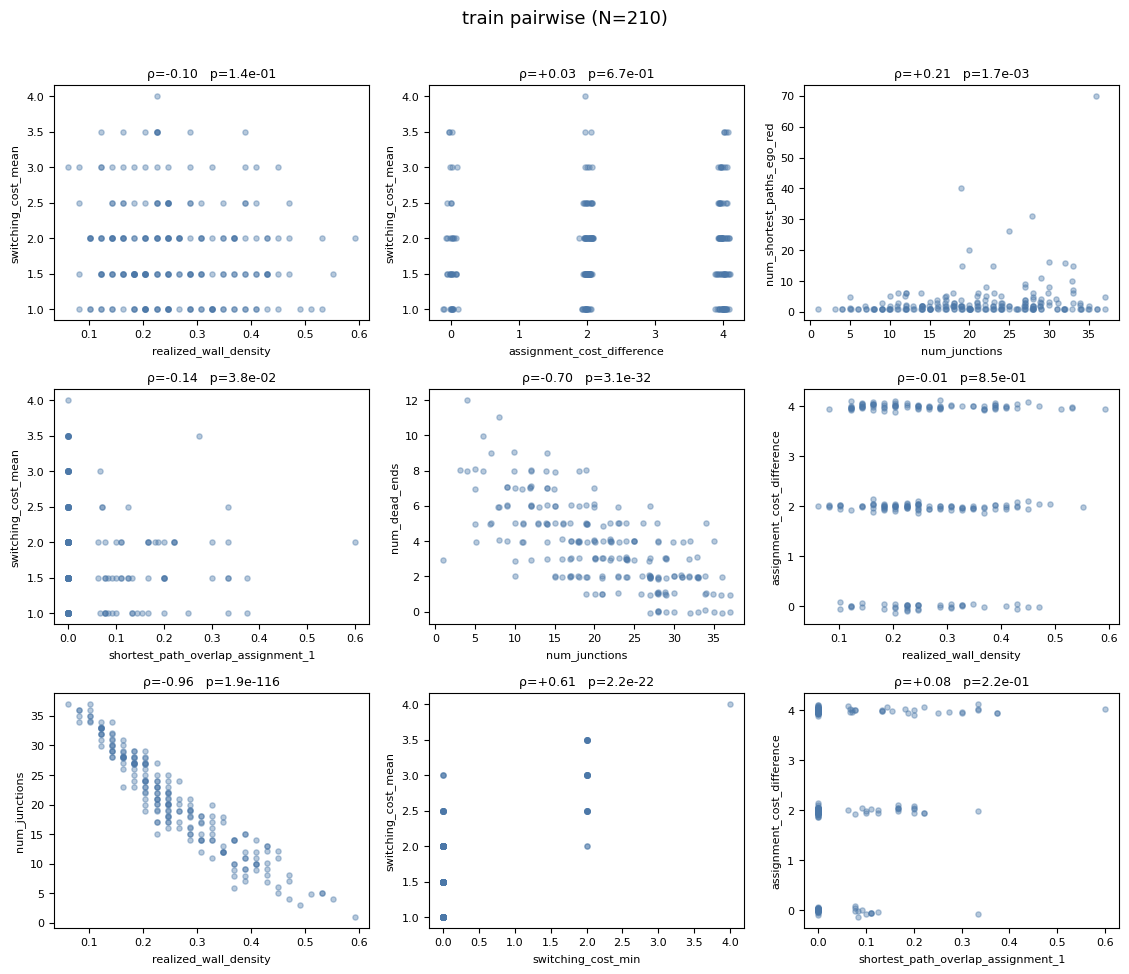

In [4]:
PAIRS = [
    ("realized_wall_density", "switching_cost_mean"),
    ("assignment_cost_difference", "switching_cost_mean"),
    ("num_junctions", "num_shortest_paths_ego_red"),
    ("shortest_path_overlap_assignment_1", "switching_cost_mean"),
    ("num_junctions", "num_dead_ends"),
    ("realized_wall_density", "assignment_cost_difference"),
    ("realized_wall_density", "num_junctions"),
    ("switching_cost_min", "switching_cost_mean"),
    ("shortest_path_overlap_assignment_1", "assignment_cost_difference"),
]

def plot_pairs(df: pd.DataFrame, pairs: List[Tuple[str, str]],
               title: str, cols: int = 3):
    n = len(pairs)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(3.8 * cols, 3.2 * rows))
    for i, (x, y) in enumerate(pairs):
        ax = axes.flat[i]
        rho, p = spearmanr(df[x], df[y])
        jitter_x = np.random.default_rng(0).normal(0, 0.05, size=len(df)) if df[x].dtype.kind in "iu" else 0
        jitter_y = np.random.default_rng(1).normal(0, 0.05, size=len(df)) if df[y].dtype.kind in "iu" else 0
        ax.scatter(df[x] + jitter_x, df[y] + jitter_y, alpha=0.4, s=14, color="#4C78A8")
        ax.set_xlabel(x, fontsize=8); ax.set_ylabel(y, fontsize=8)
        ax.set_title(f"\u03c1={rho:+.2f}   p={p:.1e}", fontsize=9)
        ax.tick_params(labelsize=8)
    for j in range(n, rows * cols):
        axes.flat[j].axis("off")
    fig.suptitle(title, fontsize=13, y=1.01)
    fig.tight_layout()
    return fig

plot_pairs(dfs["train"], PAIRS, f"train pairwise (N={len(dfs['train'])})")
plt.show()

## 3. Non-communicating baselines

Each layout is simulated `TRIALS` times per baseline through the **actual `CoordinationGrid` environment** (see `dev/coordination_grid_baselines.py`), so collision rules, wall blocking, the t=0 stationary step, the 50/50 partner-goal draw under NONE, deterministic UP > DOWN > RIGHT > LEFT tie-breaks for greedy navigation, and the step horizon all match training semantics.

Baselines (all send `NONE` throughout — no communication):

- **nearest**: ego walks toward its BFS-nearest of {RED, BLUE}.
- **fixed_RB / fixed_BR**: ego walks to a fixed goal.
- **random**: ego picks a uniform-random goal per episode.
- **wait_react**: ego STAYs for `WAIT_K` env-steps, then infers the partner's committed goal from BFS-distance change and walks to the complementary one.
- **oracle**: ego STAYs until the partner has committed (env t≥2), reads `state.partner_goal` directly, walks to the complementary goal — an upper bound isolating "did navigation fail" from "did inference fail".

Success = one agent on RED and the other on BLUE at the end of a step.

In [ ]:
# All baseline dynamics run through the CoordinationGrid env so semantics match training.
import sys
_devdir = str((Path.cwd()).resolve())
if _devdir not in sys.path:
    sys.path.insert(0, _devdir)

from coordination_grid_baselines import (
    run_baselines as _cg_run_baselines,
    ALL_BASELINES,
)

# Knobs. MAX_STEPS matches CoordinationGrid.max_steps; WAIT_K counted in env steps
# (the free-comm t=0 step is one of them by default).
MAX_STEPS = 15
WAIT_K = 2
TRIALS = 100
PARTNER_Z = 0.5

In [ ]:
def run_baselines(envs: Dict[str, dict], trials: int = TRIALS,
                  seed: int = 0) -> pd.DataFrame:
    """Thin wrapper around coordination_grid_baselines.run_baselines that
    threads the notebook-level MAX_STEPS / WAIT_K / PARTNER_Z knobs.

    Records per-baseline metrics:
      * `<name>_success`         : fraction of trials that ended in success.
      * `<name>_steps_to_success`: mean episode length over *successful* trials
                                    (NaN when a baseline never succeeded on
                                    that layout). Wait-react's wait steps
                                    count toward its total, since the env
                                    ticks state.time for them.
    """
    return _cg_run_baselines(
        envs,
        trials=trials,
        seed=seed,
        max_steps=MAX_STEPS,
        wait_k=WAIT_K,
        partner_z=PARTNER_Z,
        baselines=ALL_BASELINES,
    )


results_by_split: Dict[str, pd.DataFrame] = {}
for split in SPLITS:
    print(
        f"simulating {split} ({len(envs_by_split[split])} layouts × "
        f"{TRIALS} trials × {len(ALL_BASELINES)} baselines)..."
    )
    r = run_baselines(envs_by_split[split])
    r["triviality"] = r[["nearest_success", "wait_react_success", "random_success"]].max(axis=1)
    results_by_split[split] = r
print("done")

In [8]:
# Merge sim metrics back into per-split metadata and save.
for split in SPLITS:
    dfs[split] = dfs[split].merge(results_by_split[split], on="layout_id", how="left")
    out = CORPUS_DIR / f"{split}_baseline_results.csv"
    results_by_split[split].to_csv(out, index=False)
    print(f"wrote {out}  ({len(results_by_split[split])} rows)")

wrote grids/train_baseline_results.csv  (210 rows)
wrote grids/test_baseline_results.csv  (45 rows)
wrote grids/val_baseline_results.csv  (45 rows)


### Baseline strip/scatter
One point per layout per baseline. Deterministic baselines on unique-path layouts collapse to 0.0 or 1.0.

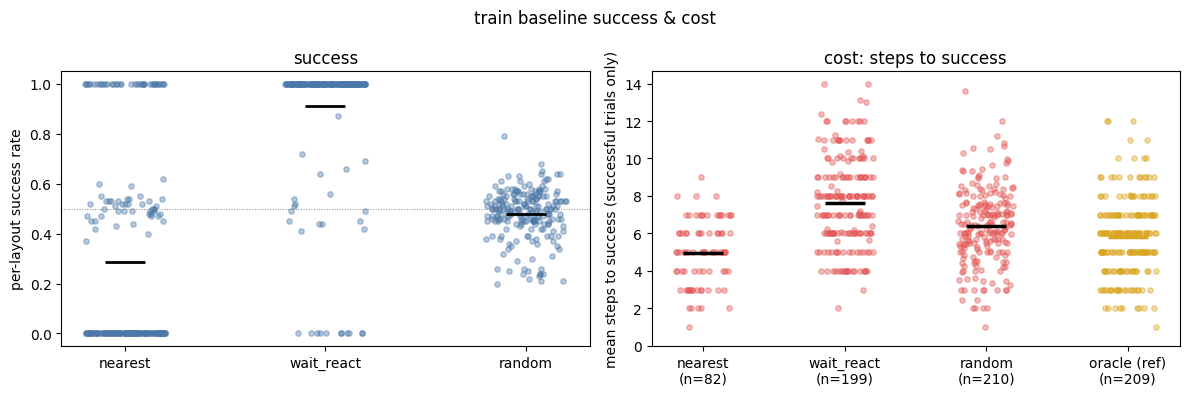

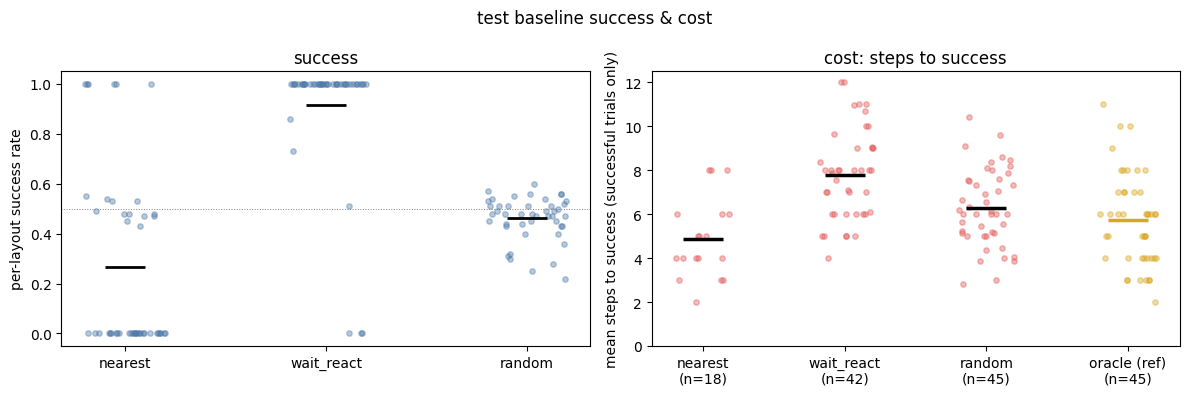

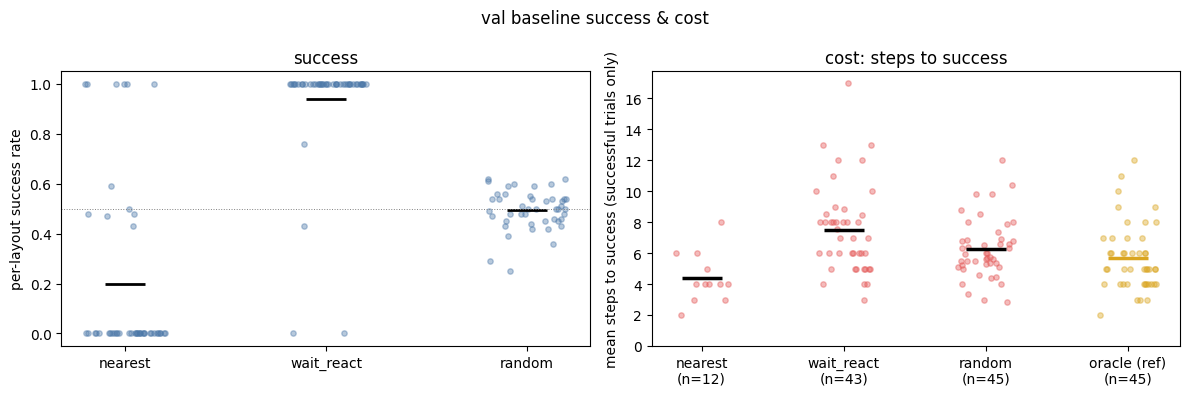

In [9]:
STRIP_BASELINES = ["nearest", "wait_react", "random"]
# Extra baselines shown only in the cost panel, as a reference floor.
COST_REFERENCES = ["oracle"]
REFERENCE_COLOR = "#DAA520"  # gold

def plot_strip(results: pd.DataFrame, title: str):
    """Two panels: per-layout success rate (left) and per-layout mean
    steps-to-success (right). Success columns: STRIP_BASELINES.
    Cost columns: STRIP_BASELINES + COST_REFERENCES — the extra reference
    baselines (e.g. oracle) show the achievable minimum cost for context.
    Their mean lines are drawn in gold.

    `steps-to-success` is NaN when a baseline never succeeds on that layout,
    so those points are dropped from the right panel (x-tick label reports
    `n=<num_layouts_with_any_success>`).
    """
    fig, (ax_s, ax_t) = plt.subplots(1, 2, figsize=(12, 4))
    rng = np.random.default_rng(0)

    # --- success panel ---
    for i, name in enumerate(STRIP_BASELINES):
        ys = results[f"{name}_success"].to_numpy()
        xs = i + rng.uniform(-0.2, 0.2, size=len(ys))
        ax_s.scatter(xs, ys, alpha=0.4, s=15, color="#4C78A8")
        ax_s.scatter([i], [ys.mean()], marker="_", s=800, color="black", linewidths=2)
    ax_s.set_xticks(range(len(STRIP_BASELINES)))
    ax_s.set_xticklabels(STRIP_BASELINES)
    ax_s.set_ylabel("per-layout success rate")
    ax_s.set_title("success")
    ax_s.set_ylim(-0.05, 1.05)
    ax_s.axhline(0.5, color="gray", ls=":", lw=0.7)

    # --- steps-to-success panel (includes cost references like oracle) ---
    cost_names = STRIP_BASELINES + COST_REFERENCES
    labels_t = []
    for i, name in enumerate(cost_names):
        ys = results[f"{name}_steps_to_success"].to_numpy()
        mask = ~np.isnan(ys)
        ys_ok = ys[mask]
        is_ref = name in COST_REFERENCES
        pt_color = REFERENCE_COLOR if is_ref else "#E45756"
        mean_color = REFERENCE_COLOR if is_ref else "black"
        xs = i + rng.uniform(-0.2, 0.2, size=len(ys_ok))
        ax_t.scatter(xs, ys_ok, alpha=0.4, s=15, color=pt_color)
        if len(ys_ok):
            ax_t.scatter([i], [ys_ok.mean()], marker="_", s=800,
                         color=mean_color, linewidths=2.5)
        tag = " (ref)" if is_ref else ""
        labels_t.append(f"{name}{tag}\n(n={mask.sum()})")
    ax_t.set_xticks(range(len(cost_names)))
    ax_t.set_xticklabels(labels_t)
    ax_t.set_ylabel("mean steps to success (successful trials only)")
    ax_t.set_title("cost: steps to success")
    ax_t.set_ylim(bottom=0)

    fig.suptitle(title, fontsize=12)
    fig.tight_layout()
    return fig

for split in SPLITS:
    plot_strip(results_by_split[split], f"{split} baseline success & cost")
    plt.show()

### Inspect extremes
Render the highest- and lowest-triviality layouts from train.

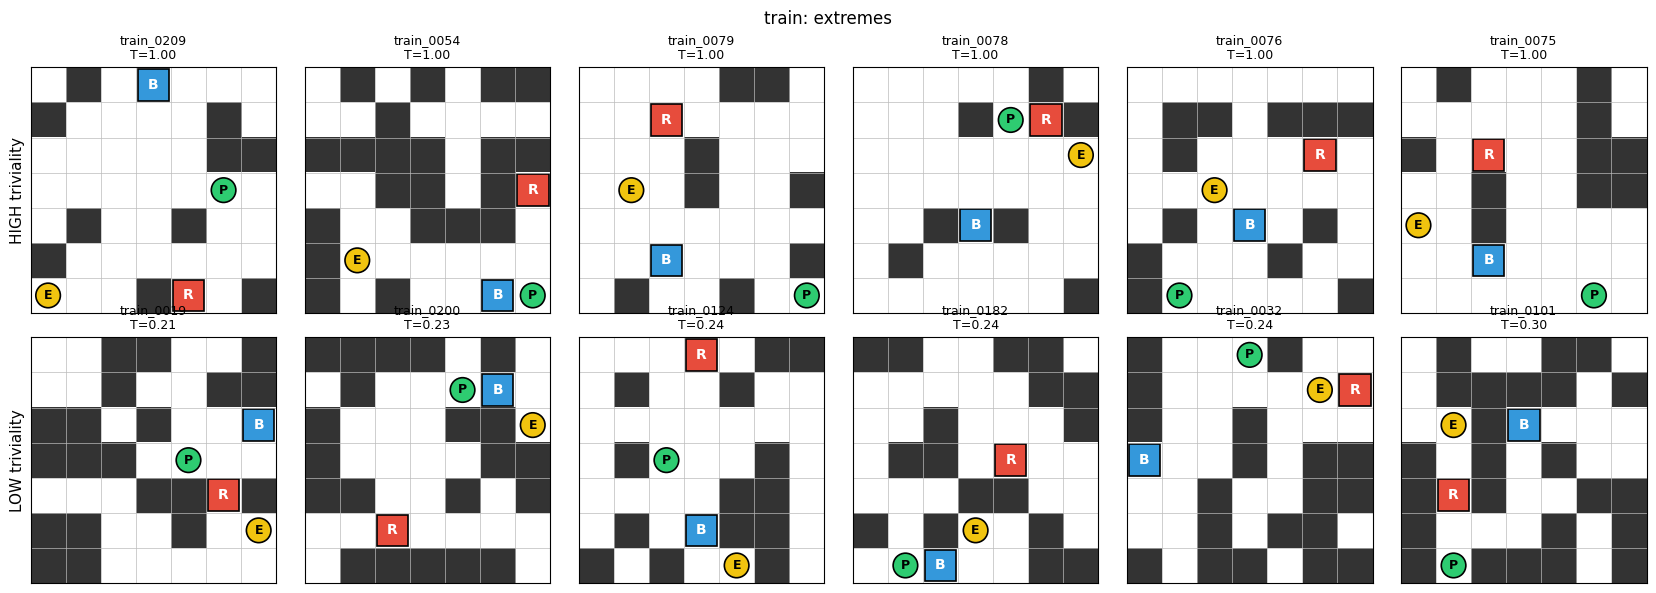

In [11]:
def plot_env_from_dict(env: dict, ax, title: str):
    arr = np.array(env["grid"], dtype=np.int8)
    walls = (arr == WALL).astype(int)
    cmap = ListedColormap(["#ffffff", "#333333"])
    ax.imshow(walls, cmap=cmap, vmin=0, vmax=1)
    H, W = walls.shape
    for k in range(max(H, W) + 1):
        ax.axhline(k - 0.5, color="#bbbbbb", lw=0.5)
        ax.axvline(k - 0.5, color="#bbbbbb", lw=0.5)
    for coord, color, label in [(env["red_goal"],  "#e74c3c", "R"),
                                 (env["blue_goal"], "#3498db", "B")]:
        r, c = coord
        ax.add_patch(Rectangle((c - 0.45, r - 0.45), 0.9, 0.9,
                                facecolor=color, edgecolor="black", lw=1.2))
        ax.text(c, r, label, ha="center", va="center", color="white", fontsize=10, fontweight="bold")
    for coord, color, label in [(env["ego_start"],     "#f1c40f", "E"),
                                 (env["partner_start"], "#2ecc71", "P")]:
        r, c = coord
        ax.add_patch(Circle((c, r), 0.35, facecolor=color, edgecolor="black", lw=1.2))
        ax.text(c, r, label, ha="center", va="center", fontsize=9, fontweight="bold")
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlim(-0.5, W - 0.5); ax.set_ylim(H - 0.5, -0.5)
    ax.set_title(title, fontsize=9)


def show_extremes(split: str, k: int = 6):
    r = results_by_split[split].sort_values("triviality")
    lowest = r.head(k)
    highest = r.tail(k).iloc[::-1]
    envs = envs_by_split[split]

    fig, axes = plt.subplots(2, k, figsize=(2.8 * k, 6))
    for i, (_, row) in enumerate(highest.iterrows()):
        env = envs[row["layout_id"]]
        plot_env_from_dict(env, axes[0, i], f"{row['layout_id']}\nT={row['triviality']:.2f}")
    axes[0, 0].set_ylabel("HIGH triviality", fontsize=11)
    for i, (_, row) in enumerate(lowest.iterrows()):
        env = envs[row["layout_id"]]
        plot_env_from_dict(env, axes[1, i], f"{row['layout_id']}\nT={row['triviality']:.2f}")
    axes[1, 0].set_ylabel("LOW triviality", fontsize=11)
    fig.suptitle(f"{split}: extremes", fontsize=12)
    fig.tight_layout()
    return fig

show_extremes("train", k=6)
plt.show()

Notes: make the P's policy more complicated (action level)
E needs to figure out -- which goal is P going to? 

Bottomline: learning partner-specific representation through actions (replicating Mon-Williams)
- And THEN add communication on top of that